# MissForestImputer Demonstration
This notebook reproduces the scratch workflow using the new `MissForestImputer` utility.
It creates a noisy sine wave, injects missing values, runs iterative imputation, and visualizes results.

In [1]:
# Local path helper (same pattern as other example notebooks)
from utils import fix_pythonpath_if_working_locally
fix_pythonpath_if_working_locally()

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from darts import TimeSeries
from darts.imputation import MissForestImputer

In [2]:
def generate_noisy_sine_wave(n_samples=500, noise_level=0.15, offset=0.1):
    t = np.linspace(0, 50, n_samples)
    y = np.sin(t) + noise_level * np.random.randn(n_samples) + offset
    return pd.Series(y, index=pd.date_range(start='2020-01-01', periods=n_samples, freq='D'))

# Create base series
base_series = generate_noisy_sine_wave()

# Inject 15% random NaNs
rng = np.random.default_rng(1)
nan_idx = rng.choice(base_series.index, size=int(0.15 * len(base_series)), replace=False)
base_series.loc[nan_idx] = np.nan

original_nan_mask = base_series.isna()
print(f'Missing points: {original_nan_mask.sum()} / {len(base_series)}')

Missing points: 75 / 500


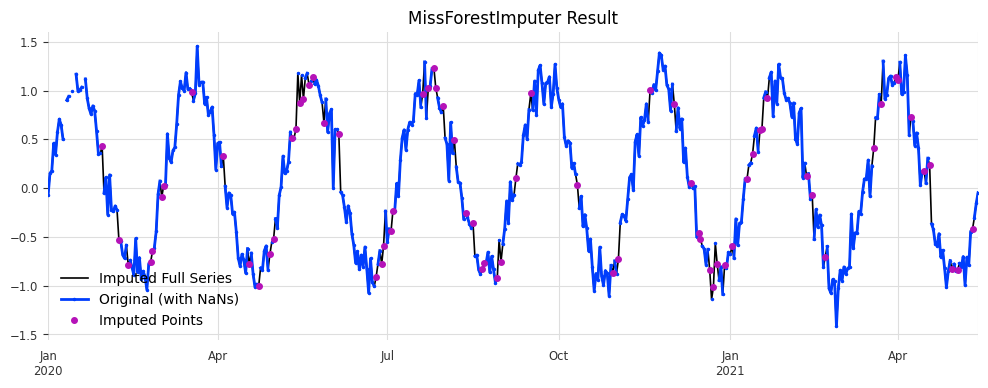

In [7]:
# Convert to TimeSeries
ts = TimeSeries.from_series(base_series)

# Instantiate the imputer (3 refinement rounds, one-step refinement, final multi-step horizon=1)
imputer = MissForestImputer(lags=24, forecast_horizon=1, n_rounds=1)
imputed_ts = imputer.fit_transform(ts)

# Extract pandas series for comparison
imputed_series = imputed_ts.to_series()
observed_series = ts.to_series()

# Build a series containing only the imputed points (NaN elsewhere)
imputed_only = imputed_series.copy()
imputed_only[~original_nan_mask] = np.nan  # keep only positions that were originally missing

fig, ax = plt.subplots(figsize=(12,4))
imputed_series.plot(ax=ax, lw=1.2, label='Imputed Full Series')
observed_series.plot(ax=ax, style='.-', lw=2, ms=3, label='Original (with NaNs)')

imputed_only.plot(ax=ax, ls='', marker='o', ms=4, label='Imputed Points')
ax.legend()
ax.set_title('MissForestImputer Result')
plt.show()

In [4]:
# Simple diagnostic: compare variance or distribution before/after (excluding NaNs)
orig_clean = observed_series.dropna()
imp_clean = imputed_series.loc[orig_clean.index]
print('Original (non-missing) mean/std:', orig_clean.mean(), orig_clean.std())
print('Imputed (observed subset) mean/std:', imp_clean.mean(), imp_clean.std())

# Show first few imputed values
print('Sample of newly imputed values:')
print(imputed_series[original_nan_mask].head(10))

Original (non-missing) mean/std: 0.11018456853705305 0.7235472306430731
Imputed (observed subset) mean/std: 0.11018456853705305 0.7235472306430731
Sample of newly imputed values:
2020-01-10         NaN
2020-01-13         NaN
2020-01-15         NaN
2020-01-20         NaN
2020-01-30    0.427965
2020-02-08   -0.532802
2020-02-13   -0.789891
2020-02-25   -0.760722
2020-02-26   -0.647383
2020-03-02   -0.092475
Name: 0, dtype: float64
